In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az
from devreact import figures
from devreact import task
from devreact import model

model_name = 'neural-dual-v5'

fig_dir = Path(os.environ['REMIND_FIGURES']) / 'model' / model_name
fig_dir.mkdir(parents=True, exist_ok=True)

%matplotlib inline
figures.set_style()
max_time = 8

In [2]:
trace = az.from_netcdf(fig_dir / 'trace.nc')

In [3]:
# range of ages to get estimates for
ages = np.arange(6, 34, .1)
age_ticks = np.arange(5, 36, 5)
age_lim = np.array([5, 35])

## Participant drift rate intercepts

In [4]:
figsize = (5, 5)
ylim = (-1, 8)

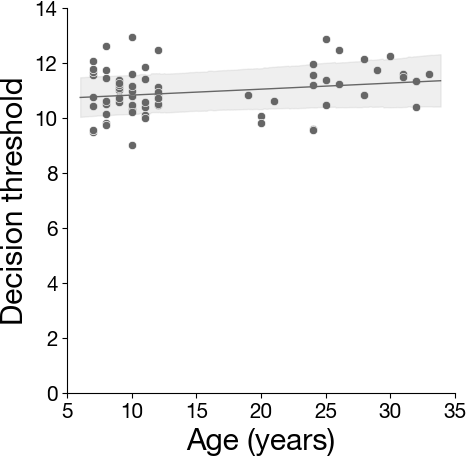

In [5]:
fig, ax = plt.subplots(figsize=figsize)
figures.plot_age_param(
    trace, 'b', ages, age_ticks, ax=ax, color=(.4, .4, .4), log=True
)
ax.set(ylabel='Decision threshold', ylim=(0, 14))
figures.savefig(fig, fig_dir / 'b.pdf')

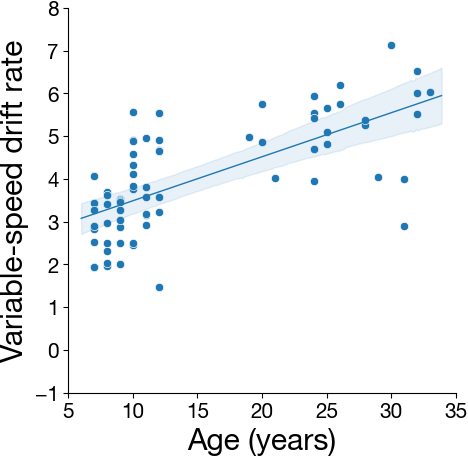

In [6]:
fig, ax = plt.subplots(figsize=figsize)
figures.plot_age_param(trace, 'v2', ages, age_ticks, ax=ax)
ax.set(ylabel='Variable-speed drift rate', ylim=ylim)
figures.savefig(fig, fig_dir / 'v2.pdf')

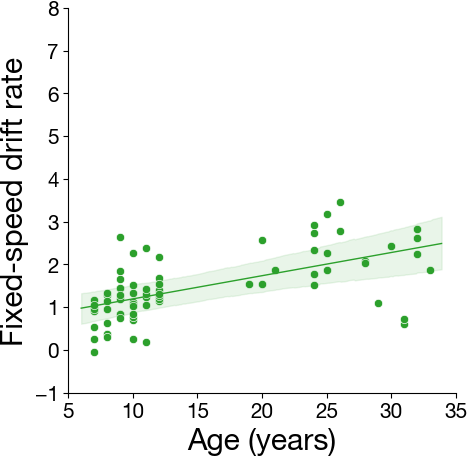

In [7]:
fig, ax = plt.subplots(figsize=figsize)
figures.plot_age_param(trace, 'v1', ages, age_ticks, color='C2', ax=ax)
ax.set(ylabel='Fixed-speed drift rate', ylim=ylim)
figures.savefig(fig, fig_dir / 'v1.pdf')

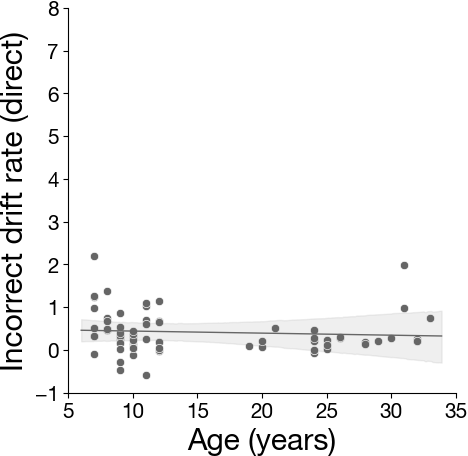

In [8]:
fig, ax = plt.subplots(figsize=figsize)
figures.plot_age_param(trace, 'v3', ages, age_ticks, color=(0.4, 0.4, 0.4), ax=ax)
ax.set(ylabel='Incorrect drift rate (direct)', ylim=ylim)
figures.savefig(fig, fig_dir / 'v3.pdf')

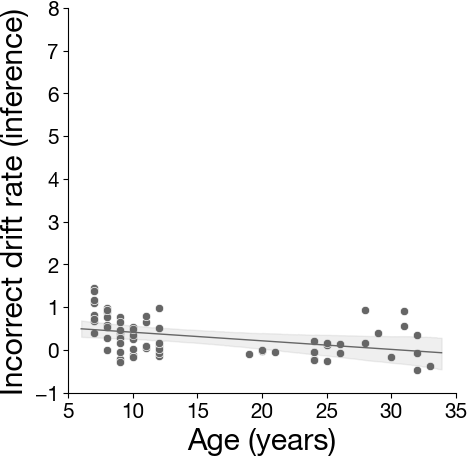

In [9]:
fig, ax = plt.subplots(figsize=figsize)
figures.plot_age_param(trace, 'v4', ages, age_ticks, color=(0.4, 0.4, 0.4), ax=ax)
ax.set(ylabel='Incorrect drift rate (inference)', ylim=ylim)
figures.savefig(fig, fig_dir / 'v4.pdf')

## Neural drift rate slope parameters

In [10]:
figsize = (6.5, 6.5)

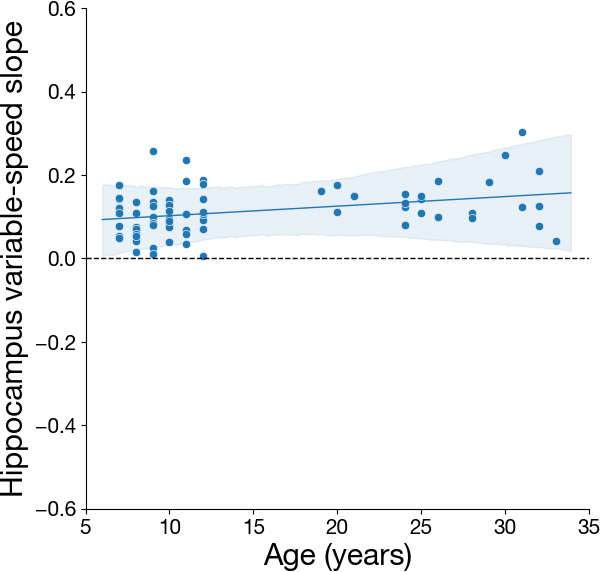

In [11]:
fig, ax = plt.subplots(figsize=figsize)
figures.plot_age_param(trace, 'v2_hpc', ages, age_ticks, absmax=0.6, ax=ax)
ax.set(ylabel='Hippocampus variable-speed slope', yticks=np.arange(-.6, .61, .2))
figures.savefig(fig, fig_dir / 'slope_hpc_v2.pdf')

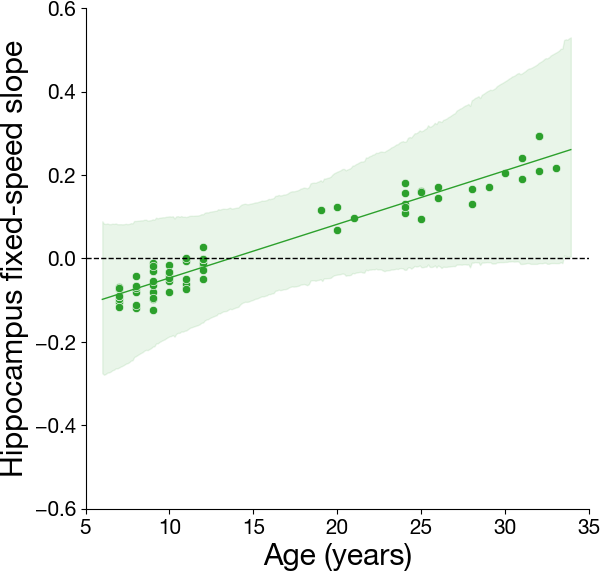

In [12]:
fig, ax = plt.subplots(figsize=figsize)
figures.plot_age_param(trace, 'v1_hpc', ages, age_ticks, absmax=0.6, color='C2', ax=ax)
ax.set(ylabel='Hippocampus fixed-speed slope', yticks=np.arange(-.6, .61, .2))
figures.savefig(fig, fig_dir / 'slope_hpc_v1.pdf')

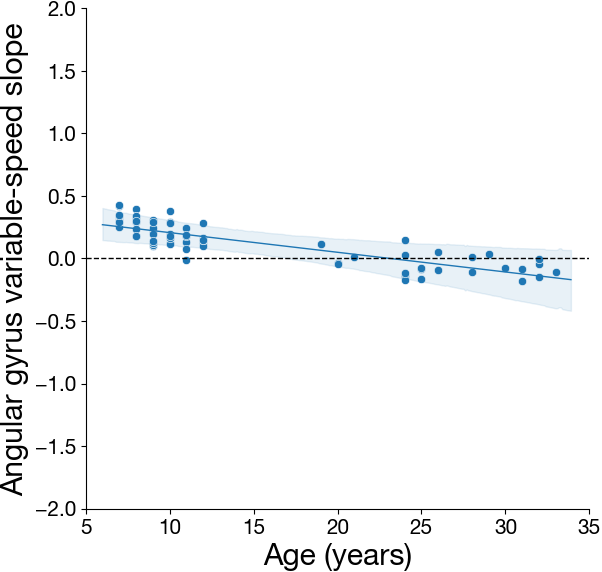

In [13]:
fig, ax = plt.subplots(figsize=figsize)
figures.plot_age_param(trace, 'v2_ang', ages, age_ticks, absmax=2, ax=ax)
ax.set(ylabel='Angular gyrus variable-speed slope', yticks=np.arange(-2, 2.01, .5))
figures.savefig(fig, fig_dir / 'slope_ang_v2.pdf')

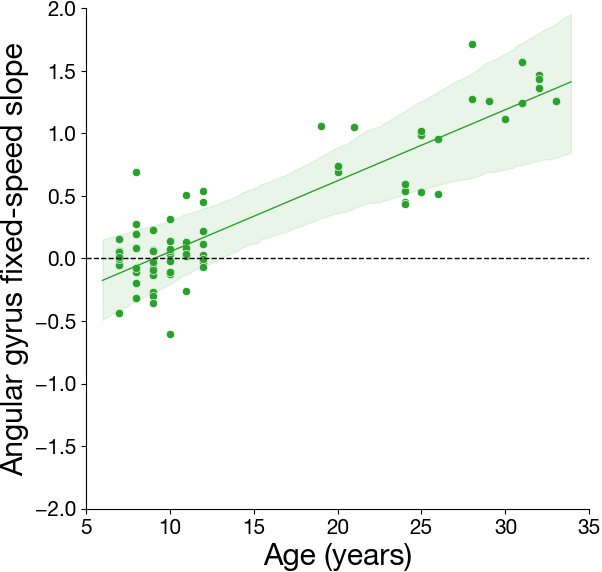

In [14]:
fig, ax = plt.subplots(figsize=figsize)
figures.plot_age_param(trace, 'v1_ang', ages, age_ticks, absmax=2, color='C2', ax=ax)
ax.set(ylabel='Angular gyrus fixed-speed slope', yticks=np.arange(-2, 2.01, .5))
figures.savefig(fig, fig_dir / 'slope_ang_v1.pdf')

## Neural signal slope

In [15]:
signal_names = ['vlpfc', 'prec', 'ang', 'lpc', 'hpc', 'phc']
roi_names = ['VLPFC', 'Precuneus', 'Angular gyrus', 'IPS/SPL', 'Hippocampus', 'PHC']

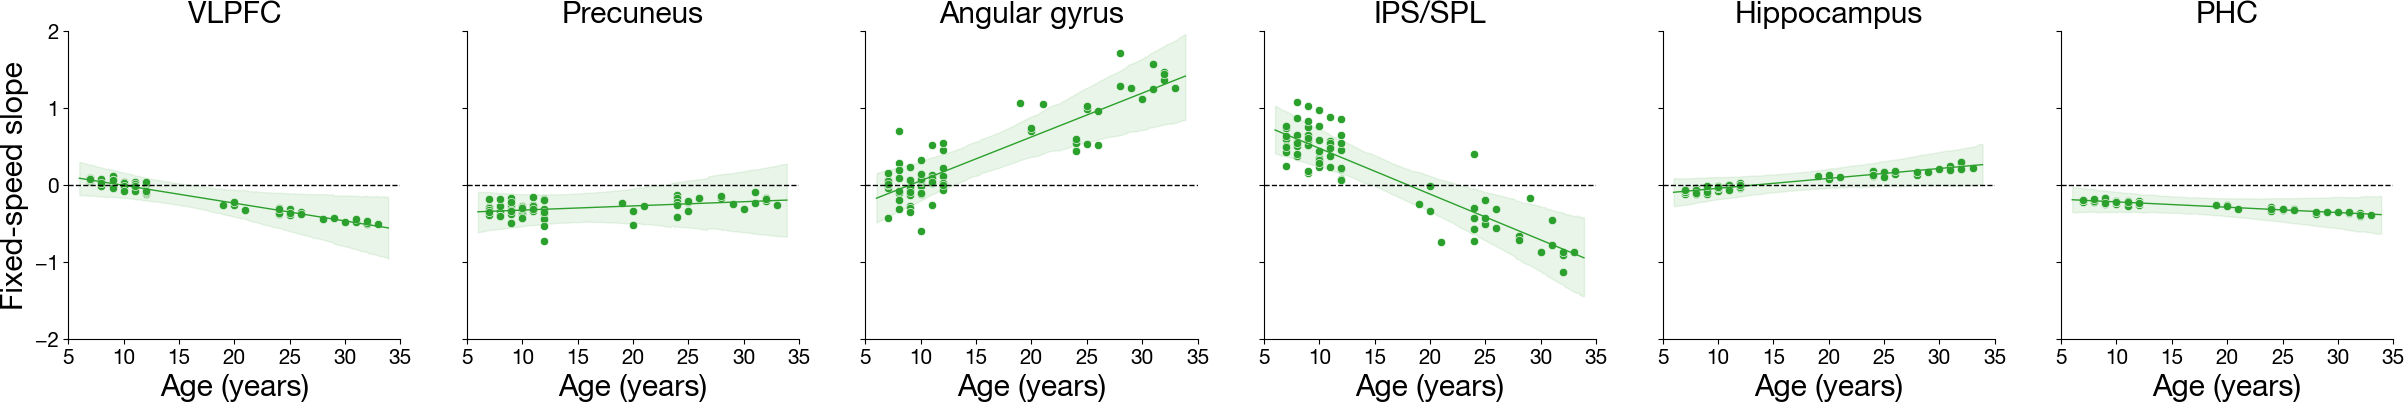

In [16]:
param_name = 'v1'
fig, ax = figures.plot_signal_slopes(
    trace, param_name, signal_names, roi_names, ages=ages, age_ticks=age_ticks, color='C2', absmax=2
)
ax[0].set_ylabel('Fixed-speed slope')
figures.savefig(fig, fig_dir / f'slope_{param_name}.pdf')

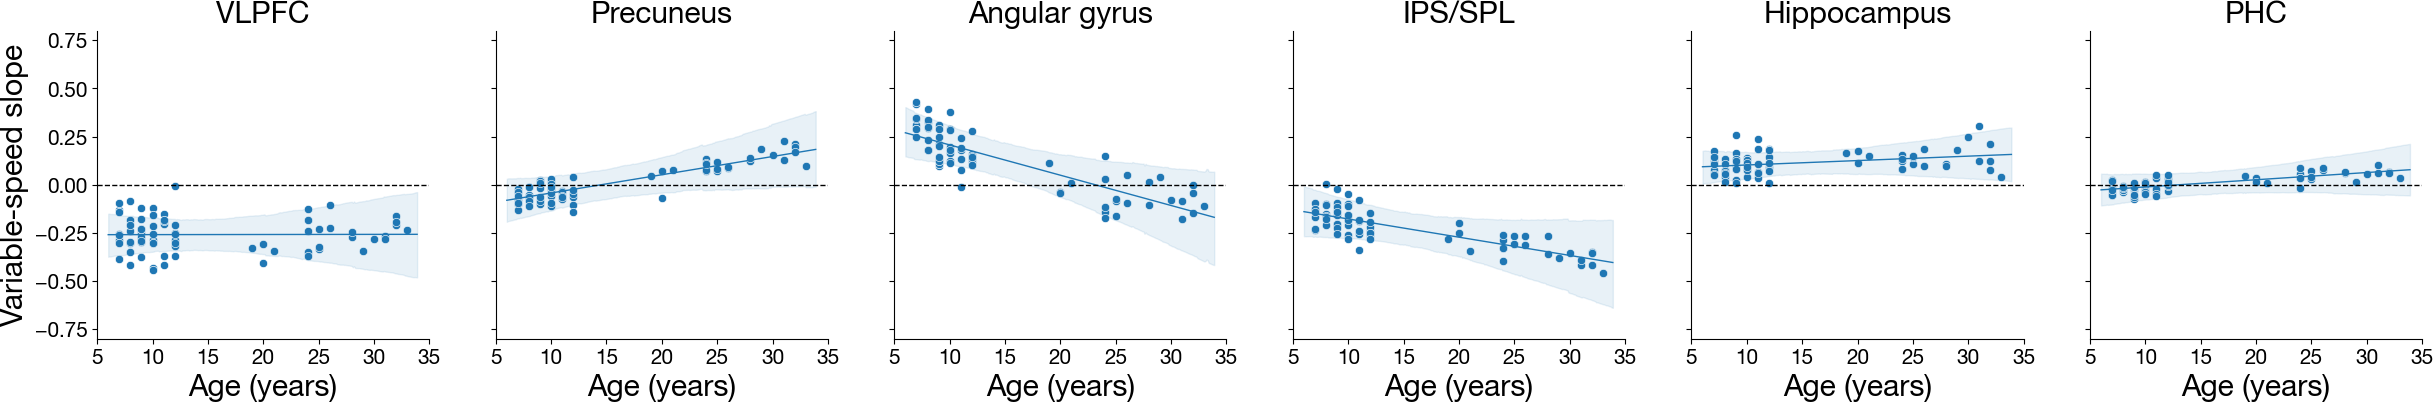

In [17]:
param_name = 'v2'
fig, ax = figures.plot_signal_slopes(
    trace, param_name, signal_names, roi_names, ages=ages, age_ticks=age_ticks, absmax=.8
)
ax[0].set_ylabel('Variable-speed slope')
figures.savefig(fig, fig_dir / f'slope_{param_name}.pdf')

## Neural signal slope age coefficients

In [18]:
coef_vars = ['b0', 'b1']
coef_labels = ['Intercept', 'Slope']

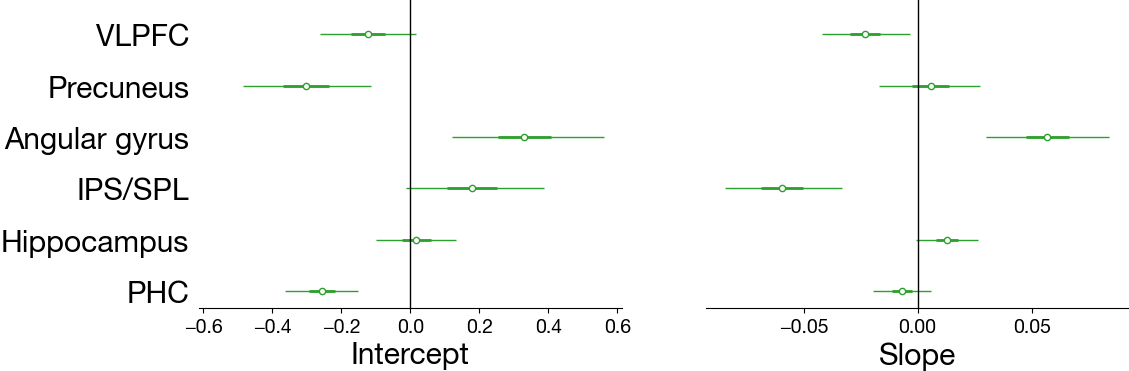

In [19]:
param_name = 'v1'
fig, ax = figures.plot_signal_coef(
    trace, coef_vars, param_name, signal_names, coef_labels, roi_names, colors=['C2']
)
figures.savefig(fig, fig_dir / f'slope_coef_{param_name}.pdf')

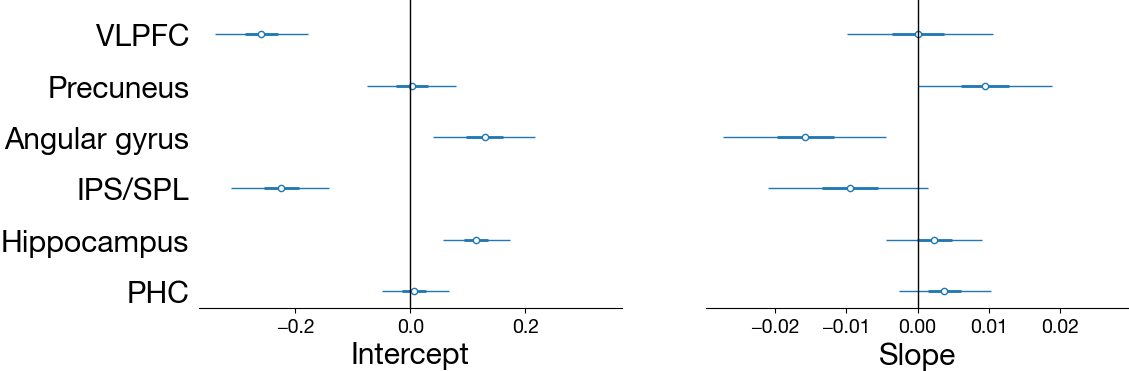

In [20]:
param_name = 'v2'
fig, ax = figures.plot_signal_coef(
    trace, coef_vars, param_name, signal_names, coef_labels, roi_names
)
figures.savefig(fig, fig_dir / f'slope_coef_{param_name}.pdf')

In [21]:
%load_ext watermark
%watermark -v -iv

Python implementation: CPython
Python version       : 3.10.5
IPython version      : 8.5.0

matplotlib: 3.6.0
numpy     : 1.21.6
seaborn   : 0.11.2
arviz     : 0.12.1
pandas    : 1.5.0
pymc      : 4.2.0
devreact  : 0.1.0

